In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

In [ ]:
Churn_client= pd.read_csv("Dataset_churn.csv")
Churn_client

,msisdn,tenure_mths_cnt,gadget_type,device_category,smart_phone_flag,manufacturer,active_days_count_mth2,active_days_count_mth3,active_days_count_mth4,data_active_days_count_mth2,...,avg_paid_data_usage,avg_voice_usage,avg_voice_onnet_usage,avg_voice_offnet_usage,avg_recharge_tot_amount,max_recharge_tot_amount,active_days_count_diff_mth2_3,active_days_count_diff_mth3_4,avg_active_days_diff,value_segment
0,028D60F7F40E18BC63C43883B6B6EFD7,0.000000,unknown,Unknown,Unknown,unknown,0.000000,0.131148,0.032258,0.000000,...,3.392080e-04,0.001130,0.001445,0.000000,0.000170,0.000411,0.733333,0.406593,0.483871,Medium
1,4AB05A575719E7BFC3DD30968D608367,0.405738,mobile handset,2G,No,itel,0.129032,0.180328,0.032258,0.096774,...,0.000000e+00,0.000970,0.001241,0.000000,0.000158,0.000316,0.766667,0.439560,0.548387,Low
2,47366A6051322F08A46B327FBBAD03AC,0.086066,mobile handset,2G,No,itel,0.032258,0.081967,0.129032,0.032258,...,0.000000e+00,0.000749,0.000745,0.000503,0.000035,0.000047,0.866667,0.340659,0.451613,Low
3,B7221E307F39F210781D6E9529B213D1,0.057377,unknown,Unknown,Unknown,unknown,0.000000,0.049180,0.129032,0.032258,...,6.340000e-07,0.000004,0.000001,0.000009,0.000000,0.000000,0.900000,0.318681,0.435484,Low
4,A6086B2E16BF1630AD75AEA6D21714C2,0.040984,mobile handset,2G,No,tecno,0.774194,0.721311,0.032258,0.032258,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.802198,0.870968,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91359,654DEFDC7578BA01E387D0E6DDE54B34,0.221311,mobile handset,2G,No,itel,0.580645,0.655738,0.806452,0.000000,...,0.000000e+00,0.000539,0.000690,0.000000,0.000111,0.000126,0.266667,0.494505,0.387097,Low
91360,B71BCFA51DF724AF26608EBEA73F478C,0.131148,mobile handset,2G,No,other,0.096774,0.131148,0.258065,0.000000,...,0.000000e+00,0.002026,0.002060,0.001257,0.000192,0.000237,0.833333,0.329670,0.419355,Low
91361,F11DF3E6E69D487A8787701F56AC0CC4,0.004098,mobile handset,Non-Data,No,itel,0.870968,0.655738,0.451613,0.032258,...,0.000000e+00,0.002060,0.002635,0.000000,0.000697,0.001170,0.566667,0.615385,0.709677,Low
91362,DDABC68BFDFB39F967ECE77F7BA291AD,0.024590,mobile handset,Non-Data,No,samsung,0.129032,0.229508,0.193548,0.000000,...,0.000000e+00,0.000822,0.000051,0.002364,0.000216,0.000364,0.666667,0.417582,0.467742,Low


In [ ]:
# 1. Remplacer les 'unknown' par NaN
# 1. Remplacer les 'unknown' par NaN
df_str = Churn_client.astype(str).apply(lambda x: x.str.lower())
masque_unknown = df_str.apply(lambda x: x.str.contains('unknow', regex=False))

for col in Churn_client.columns:
    if col in masque_unknown.columns:
        Churn_client.loc[masque_unknown[col], col] = np.nan

# 2. Convertir et nettoyer les annotations scientifiques -> NaN
pattern_scientifique = r'^[+-]?\d+(\.\d+)?[eE][+-]?\d+$'
masque_sci = Churn_client.astype(str).apply(lambda x: x.str.match(pattern_scientifique))
cols_sci = masque_sci.sum()[masque_sci.sum() > 0].index.tolist()

for col in cols_sci:
    Churn_client[col] = pd.to_numeric(Churn_client[col], errors='coerce')

# 3. Imputation par le MODE pour les colonnes contenant initialement des 'unknown' (variables catégorielles)
cols_unknown = masque_unknown.sum()[masque_unknown.sum() > 0].index.tolist()
cols_categoriques = ['gadget_type', 'device_category', 'smart_phone_flag', 'manufacturer']

for col in cols_categoriques:
    # Calcul du mode en ignorant les NaN
    mode_val = Churn_client[col].dropna().mode()[0]
    # Remplacement des NaN par la valeur du mode
    Churn_client[col] = Churn_client[col].fillna(mode_val)
    
# 4. Imputation par la MÉDIANE pour les colonnes contenant des annotations scientifiques (variables numériques)
for col in cols_sci:
    if Churn_client[col].isnull().sum() > 0:
        mediane_val = Churn_client[col].median()
        Churn_client[col] = df[col].fillna(mediane_val)

print("Imputation terminée avec succès !")
print(f"NaN restants dans les colonnes à 'unknown' : {Churn_client[cols_unknown].isnull().sum().sum()}")

print(f"NaN restants dans les colonnes à annotations scientifiques : {Churn_client[cols_sci].isnull().sum().sum()}")

Imputation terminée avec succès !
NaN restants dans les colonnes à 'unknown' : 0
NaN restants dans les colonnes à annotations scientifiques : 0


In [ ]:
 # Assurez-vous d'avoir scikit-learn à jour (>= 1.3)

# 1. Création de la cible basée sur mth2 (novembre - mois le plus récent)
# Churn (1) = 0 jour d'activité en mth2, Actif (0) = au moins 1 jour
Churn_client['churn'] = np.where(Churn_client['active_days_count_mth2'] == 0, 1, 0)

# 2. Séparation des features (X) et de la cible (y)
# ATTENTION : On ajoute 'active_days_count_mth2' dans la liste d'exclusion pour éviter le Data Leakage !
cols_to_drop = ['churn', 'msisdn', 'active_days_count_mth2']

# On garde uniquement les colonnes qui existent vraiment dans le dataset pour éviter les erreurs
cols_to_drop = [c for c in cols_to_drop if c in Churn_client.columns]

X = Churn_client.drop(columns=cols_to_drop)
y = Churn_client['churn'] # Correction ici : 'churn' au lieu de 'target'

# 3. Split Train / Test stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Target Encoding sur les variables catégorielles
cols_candidats = ['device_category', 'manufacturer', 'gadget_type', 'smart_phone_flag', 'value_segment']
cols_to_target_encode = [col for col in cols_candidats if col in X_train.columns]

# Encodage avec lissage automatique et validation croisée pour éviter l'overfitting
encoder = TargetEncoder(smooth="auto", cv=5)

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Fit et Transform sur le Train
X_train_encoded[cols_to_target_encode] = encoder.fit_transform(X_train[cols_to_target_encode], y_train)
# Uniquement Transform sur le Test
X_test_encoded[cols_to_target_encode] = encoder.transform(X_test[cols_to_target_encode])

print(f"✓ Cible créée sur mth2 (Taux de churn : {y.mean():.2%})")
print(f"✓ Colonnes encodées : {cols_to_target_encode}")
print(f"✓ Forme de X_train_encoded : {X_train_encoded.shape}")

✓ Cible créée sur mth2 (Taux de churn : 6.46%)
✓ Colonnes encodées : ['device_category', 'manufacturer', 'gadget_type', 'smart_phone_flag', 'value_segment']
✓ Forme de X_train_encoded : (73091, 60)


In [ ]:
# 1. Copie des DataFrames encodés pour conserver une sauvegarde
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

# 2. Identification des colonnes numériques à standardiser
# (On peut standardiser toutes les colonnes de X car elles sont maintenant toutes numériques)
cols_to_scale = X_train_encoded.columns.tolist()

# 3. Initialisation du RobustScaler
scaler = RobustScaler()

# 4. Fitting uniquement sur X_train et transformation de X_train et X_test
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train_encoded[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test_encoded[cols_to_scale])

print("✓ Standardisation (RobustScaler) appliquée avec succès !")
print(f"✓ Forme de X_train_scaled : {X_train_scaled.shape}")
print(f"✓ Forme de X_test_scaled  : {X_test_scaled.shape}")

✓ Standardisation (RobustScaler) appliquée avec succès !
✓ Forme de X_train_scaled : (73091, 60)
✓ Forme de X_test_scaled  : (18273, 60)


In [ ]:
from imblearn.over_sampling import SMOTE

# Application de SMOTE uniquement sur le jeu d'ENTRAÎNEMENT
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Distribution initiale dans y_train : \n{y_train.value_counts()}")
print(f"\nNouvelle distribution après SMOTE : \n{y_train_resampled.value_counts()}")
print("\nDimensions :")

print(
    "Avant :",
    X_train_scaled.shape
)

print(
    "Après :",
    X_train_resampled.shape
)

Distribution initiale dans y_train : 
churn
0    68373
1     4718
Name: count, dtype: int64

Nouvelle distribution après SMOTE : 
churn
0    68373
1    68373
Name: count, dtype: int64

Dimensions :
Avant : (73091, 60)
Après : (136746, 60)


DISTRIBUTION DES CLASSES

Avant SMOTE :
churn
0    68373
1     4718
Name: count, dtype: int64

Après SMOTE :
churn
0    68373
1    68373
Name: count, dtype: int64


              RÉGRESSION LOGISTIQUE


C:\Users\HOBEN\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Entraînement terminé.

Résultats :
Accuracy  : 0.9497
Precision : 0.5640
Recall    : 0.9703
F1-Score  : 0.7134
ROC-AUC   : 0.9890

Classification Report :
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     17093
           1       0.56      0.97      0.71      1180

    accuracy                           0.95     18273
   macro avg       0.78      0.96      0.84     18273
weighted avg       0.97      0.95      0.96     18273

Matrice de confusion :
[[16208   885]
 [   35  1145]]


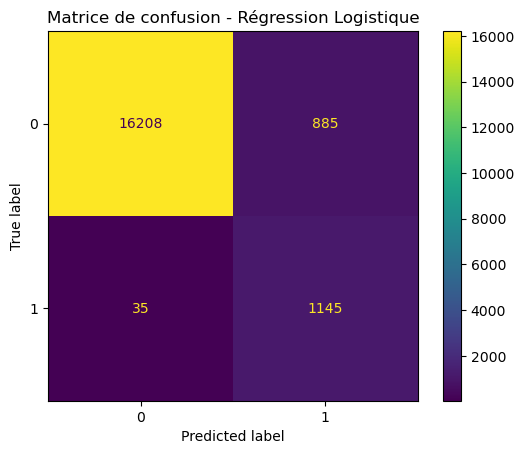



              RANDOM FOREST
Entraînement terminé.

Résultats :
Accuracy  : 0.9858
Precision : 0.8412
Recall    : 0.9610
F1-Score  : 0.8972
ROC-AUC   : 0.9983

Classification Report :
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     17093
           1       0.84      0.96      0.90      1180

    accuracy                           0.99     18273
   macro avg       0.92      0.97      0.94     18273
weighted avg       0.99      0.99      0.99     18273

Matrice de confusion :
[[16879   214]
 [   46  1134]]


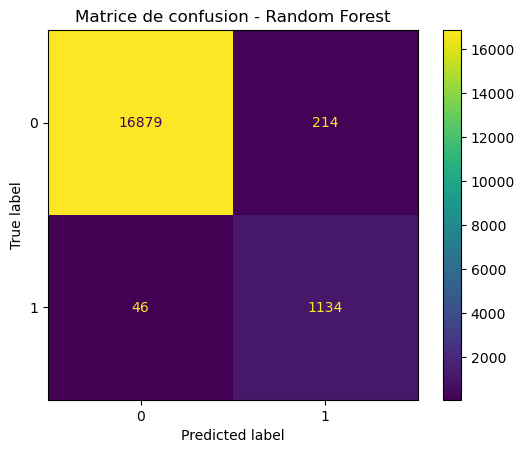



              XGBOOST
Entraînement terminé.

Résultats :
Accuracy  : 0.9952
Precision : 0.9376
Recall    : 0.9924
F1-Score  : 0.9642
ROC-AUC   : 0.9999

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17093
           1       0.94      0.99      0.96      1180

    accuracy                           1.00     18273
   macro avg       0.97      0.99      0.98     18273
weighted avg       1.00      1.00      1.00     18273

Matrice de confusion :
[[17015    78]
 [    9  1171]]


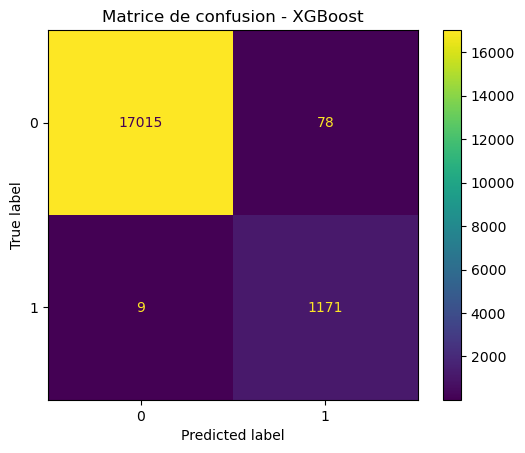



                 COMPARAISON DES 3 MODÈLES
               Modèle  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Régression Logistique  0.949652   0.564039 0.970339  0.713396 0.988985
        Random Forest  0.985771   0.841246 0.961017  0.897152 0.998315
              XGBoost  0.995239   0.937550 0.992373  0.964183 0.999884


MODÈLES CLASSÉS SELON LE F1-SCORE
               Modèle  Accuracy  Precision   Recall  F1-Score  ROC-AUC
              XGBoost  0.995239   0.937550 0.992373  0.964183 0.999884
        Random Forest  0.985771   0.841246 0.961017  0.897152 0.998315
Régression Logistique  0.949652   0.564039 0.970339  0.713396 0.988985


MODÈLES CLASSÉS SELON LE ROC-AUC
               Modèle  Accuracy  Precision   Recall  F1-Score  ROC-AUC
              XGBoost  0.995239   0.937550 0.992373  0.964183 0.999884
        Random Forest  0.985771   0.841246 0.961017  0.897152 0.998315
Régression Logistique  0.949652   0.564039 0.970339  0.713396 0.988985


In [ ]:
# ============================================================
# 1. APPLICATION DE SMOTE UNIQUEMENT SUR LE TRAIN
# ============================================================

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("====================================================")
print("DISTRIBUTION DES CLASSES")
print("====================================================")

print("\nAvant SMOTE :")
print(y_train.value_counts())

print("\nAprès SMOTE :")
print(y_train_resampled.value_counts())


# ============================================================
# 2. DÉFINITION DES 3 MODÈLES
# ============================================================

models = {

    "Régression Logistique": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )
}


# ============================================================
# 3. STOCKAGE DES RÉSULTATS
# ============================================================

results = []


# ============================================================
# 4. ENTRAÎNEMENT ET ÉVALUATION DES 3 MODÈLES
# ============================================================

for name, model in models.items():

    print("\n")
    print("=" * 70)
    print(f"              {name.upper()}")
    print("=" * 70)

    # --------------------------------------------------------
    # Entraînement
    # --------------------------------------------------------

    model.fit(
        X_train_resampled,
        y_train_resampled
    )

    print("Entraînement terminé.")

    # --------------------------------------------------------
    # Prédiction
    # --------------------------------------------------------

    y_pred = model.predict(X_test_scaled)

    # Probabilité de la classe 1
    y_pred_proba = model.predict_proba(
        X_test_scaled
    )[:, 1]

    # --------------------------------------------------------
    # Métriques
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_pred_proba
    )

    # --------------------------------------------------------
    # Sauvegarde des résultats
    # --------------------------------------------------------

    results.append({
        "Modèle": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

    # --------------------------------------------------------
    # Affichage des métriques
    # --------------------------------------------------------

    print("\nRésultats :")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")

    # --------------------------------------------------------
    # Classification report
    # --------------------------------------------------------

    print("\nClassification Report :")

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    # --------------------------------------------------------
    # Matrice de confusion
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print("Matrice de confusion :")
    print(cm)

    # --------------------------------------------------------
    # Affichage matrice
    # --------------------------------------------------------

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot()

    plt.title(
        f"Matrice de confusion - {name}"
    )

    plt.show()


# ============================================================
# 5. TABLEAU COMPARATIF
# ============================================================

results_df = pd.DataFrame(results)

print("\n")
print("=" * 70)
print("                 COMPARAISON DES 3 MODÈLES")
print("=" * 70)

print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 6. TRI SELON LE F1-SCORE
# ============================================================

results_sorted = results_df.sort_values(
    by="F1-Score",
    ascending=False
)

print("\n")
print("=" * 70)
print("MODÈLES CLASSÉS SELON LE F1-SCORE")
print("=" * 70)

print(
    results_sorted.to_string(
        index=False
    )
)


# ============================================================
# 7. TRI SELON LE ROC-AUC
# ============================================================

print("\n")
print("=" * 70)
print("MODÈLES CLASSÉS SELON LE ROC-AUC")
print("=" * 70)

print(
    results_df.sort_values(
        by="ROC-AUC",
        ascending=False
    ).to_string(index=False)
)


In [ ]:
print("Nombre de clients prédits comme churn :")
print((y_pred == 1).sum())

print("Nombre de clients prédits comme non-churn :")
print((y_pred == 0).sum())

Nombre de clients prédits comme churn :
1249
Nombre de clients prédits comme non-churn :
17024


In [ ]:
churn_count = (y_pred == 1).sum()
non_churn_count = (y_pred == 0).sum()

print("\n---------------------------------------------")
print(f"Modèle : {name}")
print("---------------------------------------------")

print(f"Total clients testés      : {len(y_pred)}")
print(f"Clients prédits CHURN     : {churn_count}")
print(f"Clients prédits NON-CHURN : {non_churn_count}")

print(f"Pourcentage CHURN         : "
      f"{churn_count / len(y_pred) * 100:.2f}%")

print(f"Pourcentage NON-CHURN     : "
      f"{non_churn_count / len(y_pred) * 100:.2f}%")


---------------------------------------------
Modèle : XGBoost
---------------------------------------------
Total clients testés      : 18273
Clients prédits CHURN     : 1249
Clients prédits NON-CHURN : 17024
Pourcentage CHURN         : 6.84%
Pourcentage NON-CHURN     : 93.16%


In [ ]:
# Total clients
total_clients = len(y_test)

# Churns réels
churn_reels = (y_test == 1).sum()

# Churns prédits
churn_predits = (y_pred == 1).sum()

# Churns capturés
churns_captures = ((y_test == 1) & (y_pred == 1)).sum()

# Pourcentages
pourcentage_reel = churn_reels / total_clients * 100
pourcentage_prediction = churn_predits / total_clients * 100
taux_detection = churns_captures / churn_reels * 100

print("==============================================")
print("INFORMATIONS CHURN")
print("==============================================")

print(f"Total clients testés       : {total_clients}")

print(f"\nChurners réels             : {churn_reels}")
print(f"Pourcentage réel            : {pourcentage_reel:.2f}%")

print(f"\nChurners prédits           : {churn_predits}")
print(f"Pourcentage de prédiction  : {pourcentage_prediction:.2f}%")

print(f"\nChurners capturés          : {churns_captures}")
print(f"Taux de détection          : {taux_detection:.2f}%")

INFORMATIONS CHURN
Total clients testés       : 18273

Churners réels             : 1180
Pourcentage réel            : 6.46%

Churners prédits           : 1249
Pourcentage de prédiction  : 6.84%

Churners capturés          : 1171
Taux de détection          : 99.24%
